In [1]:
from dofusapi import DofusAPI
from config import Config
from utils import CacheManager

import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# Set up plotting styles
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# Load the resource name cache
resource_cache = CacheManager.load_cache()
print(f"Loaded {len(resource_cache)} cached resource names")

Loaded 1611 cached resource names


In [2]:
# Fetch equipment data
equipments = DofusAPI.get_all_equipments()
print(f"Retrieved {len(equipments)} equipment items")

✅ 129 équipements récupérés avec succès
Retrieved 129 equipment items


In [3]:
# Convert to DataFrame and ensure recipe data is properly structured
df = pd.DataFrame.from_dict(equipments)

# Clean and validate recipe data
def validate_recipe(recipe):
    if not isinstance(recipe, list):
        return []
    return recipe

df['recipe'] = df['recipe'].apply(validate_recipe)
print(f"Processed {len(df)} equipment records")

Processed 129 equipment records


In [4]:
df

,ankama_id,name,type,level,image_urls,recipe
0,706,Crystal O'Boul,"{'name': 'Chapeau', 'id': 27}",72,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 3002, 'item_subtype': 'res..."
1,967,Cape Fulgurante,"{'name': 'Cape', 'id': 43}",55,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 8483, 'item_subtype': 'res..."
2,969,Couronne du Wa Wabbit,"{'name': 'Chapeau', 'id': 27}",60,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 14466, 'item_subtype': 're..."
3,971,Cape du Wa Wabbit,"{'name': 'Cape', 'id': 43}",60,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 418, 'item_subtype': 'reso..."
4,1088,Masque Kanniboul,"{'name': 'Chapeau', 'id': 27}",50,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 1678, 'item_subtype': 'res..."
...,...,...,...,...,...,...
124,27267,Cape Fulgurante Ankarton,"{'name': 'Cape', 'id': 43}",75,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,[]
125,27282,Coiffe du Bouftou Ankarton,"{'name': 'Chapeau', 'id': 27}",50,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,[]
126,27523,Cape des Rebelles,"{'name': 'Cape', 'id': 43}",50,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 27368, 'item_subtype': 're..."
127,27529,Queue de Rakoopeur,"{'name': 'Cape', 'id': 43}",50,{'icon': 'https://api.dofusdu.de/dofus3/v1/img...,"[{'item_ankama_id': 27368, 'item_subtype': 're..."


# Data Analysis and Visualization

Let's explore the equipment data to understand:
1. Distribution of equipment levels
2. Equipment types and their frequencies
3. Resource usage patterns
4. Crafting complexity analysis

In [5]:
# 1. Level Distribution Analysis
plt_level = px.histogram(df, x='level', 
                        title='Distribution of Equipment Levels',
                        labels={'level': 'Equipment Level', 'count': 'Number of Items'},
                        nbins=50)
plt_level.update_layout(showlegend=False)
plt_level.show()

# Basic statistics
print("Level Statistics:")
print(df['level'].describe())

Level Statistics:
count    129.000000
mean      71.922481
std       14.633871
min       50.000000
25%       60.000000
50%       73.000000
75%       80.000000
max      100.000000
Name: level, dtype: float64


In [6]:
# 2. Equipment Type Analysis
type_counts = df['type'].apply(lambda x: x['name']).value_counts()

plt_types = px.bar(x=type_counts.index, 
                  y=type_counts.values,
                  title='Distribution of Equipment Types',
                  labels={'x': 'Equipment Type', 'y': 'Count'})
plt_types.update_layout(xaxis_tickangle=-45)
plt_types.show()

print("\nEquipment Type Distribution:")
print(type_counts)


Equipment Type Distribution:
type
Cape       72
Chapeau    57
Name: count, dtype: int64


# Resource Analysis and Advanced Clustering

Let's analyze the resource usage patterns to improve our clustering strategy:
1. Resource frequency and rarity analysis
2. Resource acquisition difficulty (based on source/drop locations)
3. Resource cost correlation
4. Common resource combinations

In [7]:
# Extract recipe information
def extract_recipe_resources(recipe):
    if not isinstance(recipe, list):
        return []
    return [(item['item_ankama_id'], item.get('quantity', 1)) 
            for item in recipe if item.get('item_subtype') == 'resources']

# Create resource usage DataFrame
all_resources = []
for idx, row in df.iterrows():
    resources = extract_recipe_resources(row.get('recipe', []))
    for res_id, quantity in resources:
        all_resources.append({
            'equipment_name': row['name'],
            'equipment_level': row['level'],
            'equipment_type': row['type']['name'],
            'resource_id': res_id,
            'quantity': quantity
        })

resource_df = pd.DataFrame(all_resources)

# Get resource names using cache with proper fallback to API
print("Fetching resource names...")
cache_hits = 0
api_calls = 0

for res_id in resource_df['resource_id'].unique():
    str_id = str(res_id)
    if str_id in resource_cache:
        cache_hits += 1
    else:
        print(f"Fetching resource {res_id} from API...", end=' ')
        try:
            resource_cache[str_id] = DofusAPI.get_resource_name(res_id, resource_cache)
            print("✓")
            api_calls += 1
        except Exception as e:
            print(f"❌ Error: {str(e)}")
            resource_cache[str_id] = f"Unknown Resource ({res_id})"

# Save updated cache
CacheManager.save_cache(resource_cache)
print(f"\nResource name fetching complete:")
print(f"- Cache hits: {cache_hits}")
print(f"- API calls: {api_calls}")
print(f"- Total resources: {len(resource_cache)}")

# Create a mapping for easy access
resource_names = {int(k): v for k, v in resource_cache.items()}

Fetching resource names...

Resource name fetching complete:
- Cache hits: 261
- API calls: 0
- Total resources: 1611


# Bulk Purchase Optimization Analysis

Key metrics to analyze:
1. Resource overlap ratio (shared resources / total resources) per equipment group
2. Resource quantity analysis (to optimize bulk purchases)
3. Equipment crafting efficiency (number of items per resource batch)
4. Resource utilization rate (minimize leftover resources)

In [8]:
# Function to analyze resource overlap and bulk purchase efficiency
def analyze_bulk_purchase_efficiency(equipment_group):
    all_resources = {}  # resource_id -> {total_quantity, equipment_count}
    
    # Collect resource usage across equipment group
    for eq_name in equipment_group:
        recipe = df[df['name'] == eq_name].iloc[0].get('recipe', [])
        for item in recipe:
            if item.get('item_subtype') == 'resources':
                res_id = item['item_ankama_id']
                quantity = item.get('quantity', 1)
                
                if res_id not in all_resources:
                    all_resources[res_id] = {'total_quantity': 0, 'equipment_count': 0}
                    
                all_resources[res_id]['total_quantity'] += quantity
                all_resources[res_id]['equipment_count'] += 1
    
    # Calculate metrics
    total_equipment = len(equipment_group)
    total_resources = len(all_resources)
    shared_resources = sum(1 for r in all_resources.values() if r['equipment_count'] > 1)
    total_quantity = sum(r['total_quantity'] for r in all_resources.values())
    shared_quantity = sum(r['total_quantity'] for r in all_resources.values() 
                         if r['equipment_count'] > 1)
    
    return {
        'resource_overlap_ratio': (shared_resources / total_resources) if total_resources > 0 else 0,
        'quantity_efficiency': (shared_quantity / total_quantity) if total_quantity > 0 else 0,
        'items_per_resource': total_equipment / total_resources if total_resources > 0 else 0,
        'shared_resources': shared_resources,
        'total_resources': total_resources,
        'total_quantity': total_quantity
    }

In [9]:
# Function to find optimal equipment groups for bulk purchasing
def find_optimal_purchase_groups(min_overlap_ratio=0.3, min_items_per_resource=2):
    equipment_names = df['name'].tolist()
    optimal_groups = []
    
    def calculate_group_score(group):
        metrics = analyze_bulk_purchase_efficiency(group)
        return (
            metrics['resource_overlap_ratio'] * 0.4 +  # Weight for resource overlap
            metrics['quantity_efficiency'] * 0.3 +     # Weight for quantity efficiency
            metrics['items_per_resource'] * 0.3        # Weight for crafting efficiency
        )
    
    # Start with individual equipment as seeds
    for seed_eq in equipment_names:
        current_group = [seed_eq]
        current_score = calculate_group_score(current_group)
        
        # Try adding each remaining equipment
        improved = True
        while improved:
            improved = False
            best_addition = None
            best_score = current_score
            
            for eq in equipment_names:
                if eq not in current_group:
                    test_group = current_group + [eq]
                    test_score = calculate_group_score(test_group)
                    
                    if test_score > best_score:
                        best_score = test_score
                        best_addition = eq
                        improved = True
            
            if improved:
                current_group.append(best_addition)
                current_score = best_score
        
        # Check if group meets minimum criteria
        metrics = analyze_bulk_purchase_efficiency(current_group)
        if (metrics['resource_overlap_ratio'] >= min_overlap_ratio and 
            metrics['items_per_resource'] >= min_items_per_resource):
            optimal_groups.append({
                'equipment': current_group,
                'metrics': metrics,
                'score': current_score
            })
    
    # Sort groups by score
    optimal_groups.sort(key=lambda x: x['score'], reverse=True)
    return optimal_groups

In [10]:
# Find and analyze optimal purchase groups
optimal_groups = find_optimal_purchase_groups(min_overlap_ratio=0.4, min_items_per_resource=2)

# Display results for top groups
print(f"Found {len(optimal_groups)} optimal purchase groups\n")

for i, group in enumerate(optimal_groups[:5], 1):
    metrics = group['metrics']
    print(f"\nGroup {i}:")
    print(f"Score: {group['score']:.2f}")
    print(f"Equipment Count: {len(group['equipment'])}")
    print(f"Resource Overlap Ratio: {metrics['resource_overlap_ratio']:.2f}")
    print(f"Quantity Efficiency: {metrics['quantity_efficiency']:.2f}")
    print(f"Items per Resource: {metrics['items_per_resource']:.2f}")
    print("\nEquipment in group:")
    for eq in group['equipment']:
        print(f"- {eq}")
    print("-" * 50)

Found 7 optimal purchase groups


Group 1:
Score: 1.22
Equipment Count: 12
Resource Overlap Ratio: 0.60
Quantity Efficiency: 0.86
Items per Resource: 2.40

Equipment in group:
- Scaracoiffe Noire
- Scaracape Noire
- Cape du Chef Bwork
- Casque du Chef Bwork
- Casque du Roks Or
- Cape du Roks Or
- Scaphandre Magmatique
- Loupe d'improbabilité
- Bouteille de chronoxygène
- Scaphandre chronomagique
- Cape Fulgurante Ankarton
- Coiffe du Bouftou Ankarton
--------------------------------------------------

Group 2:
Score: 1.22
Equipment Count: 12
Resource Overlap Ratio: 0.60
Quantity Efficiency: 0.86
Items per Resource: 2.40

Equipment in group:
- Scaracape Noire
- Scaracoiffe Noire
- Cape du Chef Bwork
- Casque du Chef Bwork
- Casque du Roks Or
- Cape du Roks Or
- Scaphandre Magmatique
- Loupe d'improbabilité
- Bouteille de chronoxygène
- Scaphandre chronomagique
- Cape Fulgurante Ankarton
- Coiffe du Bouftou Ankarton
--------------------------------------------------

Group 3:
Score: 1.16

# Resource Overlap Analysis and Purchase Optimization

Let's analyze:
1. Resource co-occurrence patterns
2. Resource quantity distributions
3. Equipment clustering based on shared resources
4. Optimal purchase quantities

In [11]:
# Create resource co-occurrence matrix
def create_resource_matrix():
    # Get all unique resources
    all_resources = set()
    resource_equipment = {}  # resource_id -> set of equipment names
    
    for idx, row in df.iterrows():
        recipe = row.get('recipe', [])
        if not isinstance(recipe, list):
            continue
            
        equipment_name = row['name']
        
        for item in recipe:
            if isinstance(item, dict) and item.get('item_subtype') == 'resources':
                res_id = item['item_ankama_id']
                all_resources.add(res_id)
                
                if res_id not in resource_equipment:
                    resource_equipment[res_id] = set()
                resource_equipment[res_id].add(equipment_name)
    
    # Create co-occurrence matrix
    resource_list = sorted(list(all_resources))
    cooccurrence = pd.DataFrame(0, index=resource_list, columns=resource_list)
    
    # Fill matrix
    for res1 in resource_list:
        for res2 in resource_list:
            if res1 != res2:
                common_equipment = len(resource_equipment[res1].intersection(resource_equipment[res2]))
                cooccurrence.loc[res1, res2] = common_equipment
    
    return cooccurrence, resource_equipment

# Generate the matrix
cooccurrence_matrix, resource_equipment_map = create_resource_matrix()

# Find most frequently co-occurring resources
top_pairs = []
for i in range(len(cooccurrence_matrix)):
    for j in range(i + 1, len(cooccurrence_matrix)):
        if cooccurrence_matrix.iloc[i, j] > 0:
            res1 = cooccurrence_matrix.index[i]
            res2 = cooccurrence_matrix.index[j]
            count = cooccurrence_matrix.iloc[i, j]
            top_pairs.append((res1, res2, count))

top_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop co-occurring resource pairs:")
for res1, res2, count in top_pairs[:10]:
    name1 = resource_names.get(res1, f"Resource {res1}")
    name2 = resource_names.get(res2, f"Resource {res2}")
    print(f"{name1} + {name2}: {count} items in common")


Top co-occurring resource pairs:
Maillot de corps de Barbroussa + Foulard du Sparo: 19 items in common
Maillot de corps de Barbroussa + Plume de fesse du Kido: 19 items in common
Maillot de corps de Barbroussa + Aile du Bitouf des Plaines: 19 items in common
Maillot de corps de Barbroussa + Étoffe de Gourlo le Terrible: 19 items in common
Foulard du Sparo + Plume de fesse du Kido: 19 items in common
Foulard du Sparo + Aile du Bitouf des Plaines: 19 items in common
Foulard du Sparo + Étoffe de Gourlo le Terrible: 19 items in common
Plume de fesse du Kido + Aile du Bitouf des Plaines: 19 items in common
Plume de fesse du Kido + Étoffe de Gourlo le Terrible: 19 items in common
Aile du Bitouf des Plaines + Étoffe de Gourlo le Terrible: 19 items in common


In [12]:
import matplotlib.pyplot as plt
# Optimize bulk purchases based on resource co-occurrence
def optimize_bulk_purchases(min_overlap_count=2):
    purchase_groups = []
    
    def calculate_purchase_efficiency(resources):
        # Get all equipment that can be crafted with these resources
        craftable_equipment = set()
        for res_id in resources:
            equipment_set = resource_equipment_map.get(res_id, set())
            if not craftable_equipment:
                craftable_equipment = equipment_set.copy()
            else:
                craftable_equipment.intersection_update(equipment_set)
        
        # Calculate efficiency metrics
        if not craftable_equipment:
            return 0, []
        
        resource_count = len(resources)
        equipment_count = len(craftable_equipment)
        efficiency = equipment_count / resource_count if resource_count > 0 else 0
        
        return efficiency, list(craftable_equipment)
    
    # Start with highly co-occurring pairs
    processed_groups = set()
    for res1, res2, count in top_pairs:
        if count < min_overlap_count:
            continue
            
        # Start with the pair
        current_resources = {res1, res2}
        current_hash = tuple(sorted(current_resources))
        
        if current_hash in processed_groups:
            continue
            
        # Try to expand the group
        improved = True
        while improved:
            improved = False
            best_addition = None
            best_efficiency = calculate_purchase_efficiency(current_resources)[0]
            
            # Try adding each resource
            for res_id in cooccurrence_matrix.index:
                if res_id not in current_resources:
                    test_resources = current_resources | {res_id}
                    efficiency, _ = calculate_purchase_efficiency(test_resources)
                    
                    if efficiency > best_efficiency:
                        best_efficiency = efficiency
                        best_addition = res_id
                        improved = True
            
            if improved and best_addition is not None:
                current_resources.add(best_addition)
        
        # Add group if it's useful
        efficiency, craftable = calculate_purchase_efficiency(current_resources)
        if len(craftable) >= 2:  # Only keep groups that can craft multiple items
            purchase_groups.append({
                'resources': current_resources,
                'craftable_equipment': craftable,
                'efficiency': efficiency
            })
            processed_groups.add(tuple(sorted(current_resources)))
    
    return sorted(purchase_groups, key=lambda x: x['efficiency'], reverse=True)

# Find optimal purchase groups
optimal_purchases = optimize_bulk_purchases(min_overlap_count=3)

# Display results
print(f"\nFound {len(optimal_purchases)} optimal purchase groups\n")
for i, group in enumerate(optimal_purchases[:5], 1):
    print(f"\nPurchase Group {i}:")
    print(f"Efficiency Score: {group['efficiency']:.2f}")
    print(f"Resources to purchase ({len(group['resources'])}):")
    for res_id in group['resources']:
        name = resource_names.get(res_id, f"Resource {res_id}")
        print(f"- {name}")
    print(f"\nCraftable Equipment ({len(group['craftable_equipment'])}):")
    for eq in group['craftable_equipment']:
        print(f"- {eq}")
    print("-" * 50)


Found 22 optimal purchase groups


Purchase Group 1:
Efficiency Score: 9.50
Resources to purchase (2):
- Foulard du Sparo
- Maillot de corps de Barbroussa

Craftable Equipment (19):
- Cape Aillé
- Cape Lyne
- Cape Ortail
- Cape Aircussion
- Sac Rebleux
- Cape Hitton
- Cape Hulco
- Cape Huchon
- Cape Routh
- Cape Hoile
- Cape Endaison
- Cape Anthéon
- Cape Ytale
- Cape Wéra
- Cape Hadosse
- Cape Haharnum
- Cape Rimordiale
- Cape Sulhit
- Cape Aurale
--------------------------------------------------

Purchase Group 2:
Efficiency Score: 9.50
Resources to purchase (2):
- Maillot de corps de Barbroussa
- Plume de fesse du Kido

Craftable Equipment (19):
- Cape Aillé
- Cape Lyne
- Cape Ortail
- Cape Aircussion
- Sac Rebleux
- Cape Hitton
- Cape Hulco
- Cape Huchon
- Cape Routh
- Cape Hoile
- Cape Endaison
- Cape Anthéon
- Cape Ytale
- Cape Wéra
- Cape Hadosse
- Cape Haharnum
- Cape Rimordiale
- Cape Sulhit
- Cape Aurale
--------------------------------------------------

Purchase Group 3:


Visualizing the most efficient purchase group:


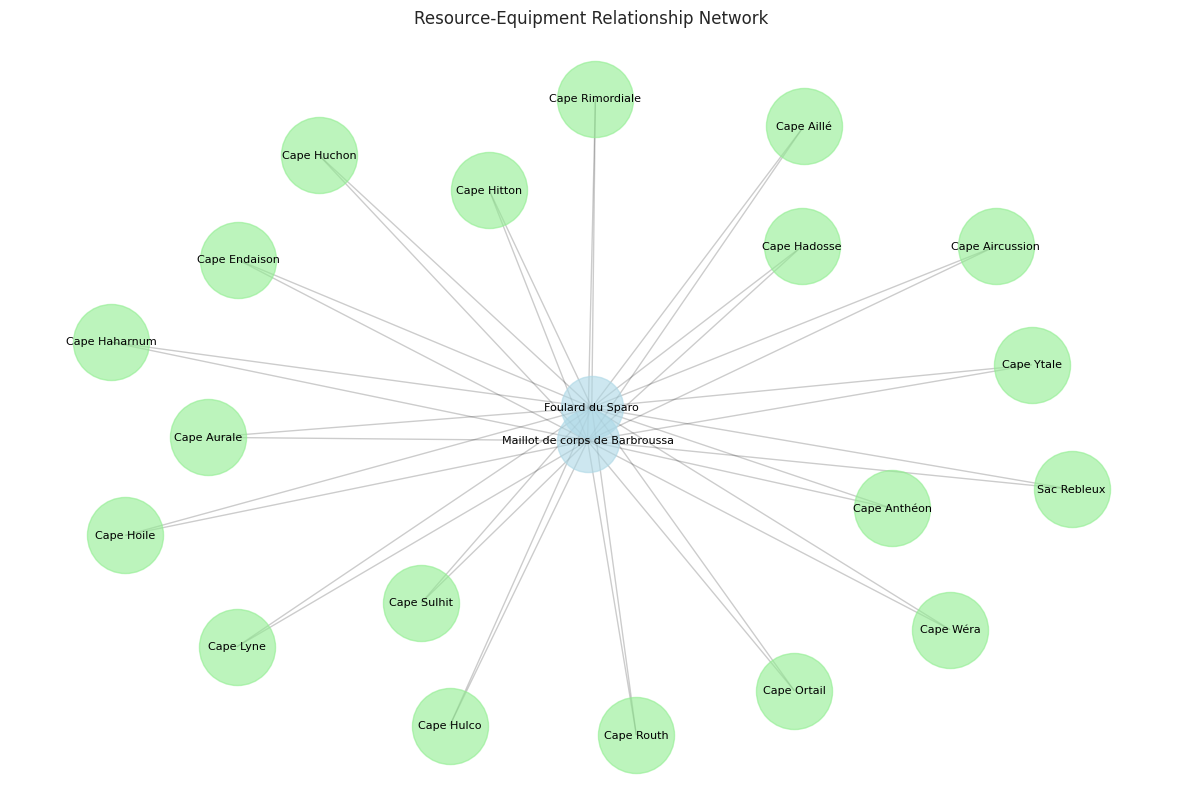

In [13]:
import matplotlib.pyplot as plt
# Create a network visualization of resource relationships
def visualize_resource_network(purchase_group):
    # Create network data
    nodes = []
    edges = []
    
    # Add resources as nodes
    for res_id in purchase_group['resources']:
        name = resource_names.get(res_id, f"Resource {res_id}")
        nodes.append(dict(id=str(res_id), label=name, group='resource'))
    
    # Add equipment as nodes
    for eq in purchase_group['craftable_equipment']:
        nodes.append(dict(id=eq, label=eq, group='equipment'))
    
    # Create edges between resources and equipment
    for eq in purchase_group['craftable_equipment']:
        recipe = df[df['name'] == eq].iloc[0].get('recipe', [])
        for item in recipe:
            if item.get('item_subtype') == 'resources' and item['item_ankama_id'] in purchase_group['resources']:
                edges.append(dict(source=str(item['item_ankama_id']), 
                                target=eq,
                                value=item.get('quantity', 1)))
    
    # Create the network graph
    import networkx as nx
    G = nx.Graph()
    
    # Add nodes
    for node in nodes:
        G.add_node(node['id'], **node)
    
    # Add edges
    for edge in edges:
        G.add_edge(edge['source'], edge['target'], weight=edge['value'])
    
    # Calculate layout
    pos = nx.spring_layout(G)
    
    # Create plot
    plt.figure(figsize=(15, 10))
    
    # Draw resource nodes
    resource_nodes = [n for n in G.nodes() if G.nodes[n]['group'] == 'resource']
    nx.draw_networkx_nodes(G, pos, nodelist=resource_nodes, node_color='lightblue', 
                          node_size=2000, alpha=0.6)
    
    # Draw equipment nodes
    equipment_nodes = [n for n in G.nodes() if G.nodes[n]['group'] == 'equipment']
    nx.draw_networkx_nodes(G, pos, nodelist=equipment_nodes, node_color='lightgreen',
                          node_size=3000, alpha=0.6)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    
    # Add labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    plt.title('Resource-Equipment Relationship Network')
    plt.axis('off')
    plt.show()

# Visualize the top purchase group
if optimal_purchases:
    print("Visualizing the most efficient purchase group:")
    visualize_resource_network(optimal_purchases[0])